### pip

In [1]:
pip install scipy 

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
pip install scipystats

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
pip install matplotlib seaborn pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Setup

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

fb = pd.read_csv(r'C:\Users\Rawr\Documents\Python Codes\CPE-311\HOA\HOA 9.1-9.2\Datasets\fb_stock_prices_2018.csv', 
                 index_col='date', parse_dates=True)

quakes = pd.read_csv(r'C:\Users\Rawr\Documents\Python Codes\CPE-311\HOA\HOA 9.1-9.2\Datasets\earthquakes-1.csv')

# Procedures

## Procedure 9.4

In [5]:
quakes.assign(
    time=lambda x: pd.to_datetime(x.time, unit='ms')
).set_index('time').loc['2018-09-28'].query(
    "parsed_place == 'Indonesia' and tsunami == 1 and mag == 7.5"
)

,mag,magType,place,tsunami,parsed_place
time,,,,,
2018-09-28 10:02:43.480,7.5,mww,"78km N of Palu, Indonesia",1,Indonesia


This code filters the earthquake data for the specific event. I see that it converts the time column from milliseconds to datetime, sets it as index, and then uses .loc to select the date and .query() for additional conditions. It returns a row showing the exact time, magnitude, place, and tsunami indicator. This is a clean way to drill down into a specific event.

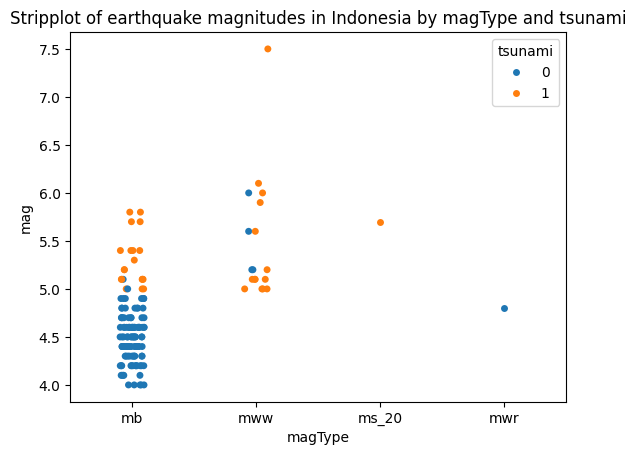

In [6]:
sns.stripplot(
    x='magType',
    y='mag',
    hue='tsunami',
    data=quakes.query('parsed_place == "Indonesia"')
)
plt.title('Stripplot of earthquake magnitudes in Indonesia by magType and tsunami')
plt.show()

Points overlap a lot, especially for mb type. It’s hard to see the density of points. The hue parameter helps distinguish tsunami vs. non-tsunami earthquakes, but overlapping makes it messy. I can see that most earthquakes in Indonesia are of type mb and have low magnitudes, but the plot is crowded.

c:\Users\Rawr\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 10.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


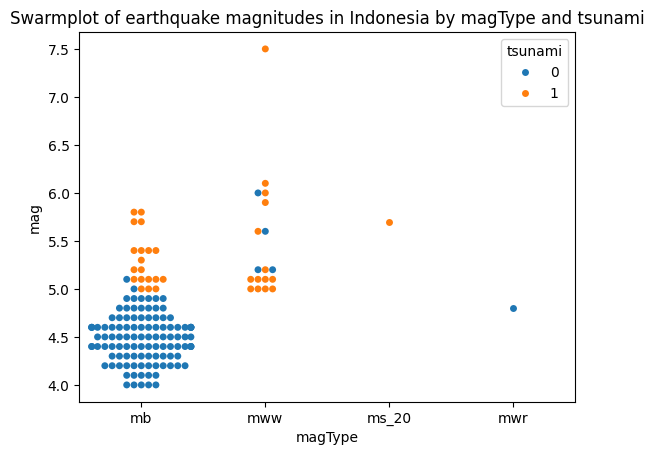

In [7]:
sns.swarmplot(
    x='magType',
    y='mag',
    hue='tsunami',
    data=quakes.query('parsed_place == "Indonesia"')
)
plt.title('Swarmplot of earthquake magnitudes in Indonesia by magType and tsunami')
plt.show()

The points don’t overlap, so I can see the distribution for each magType. The warning says 10.2% of points couldn’t be placed, meaning some adjustments might be needed. But overall, it’s clearer that mb has many points spread across magnitudes, and tsunami events (orange) are rare and tend to have higher magnitudes.

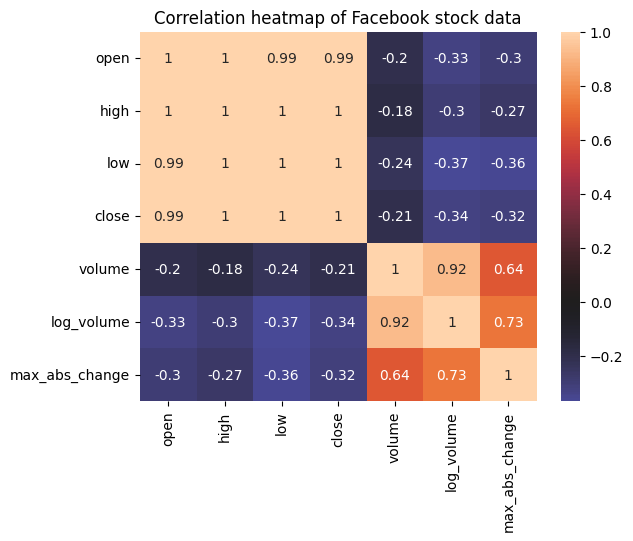

In [8]:
sns.heatmap(
    fb.sort_index().assign(
        log_volume=np.log(fb.volume),
        max_abs_change=fb.high - fb.low
    ).corr(),
    annot=True,
    center=0
)
plt.title('Correlation heatmap of Facebook stock data')
plt.show()

The heatmap shows correlations between variables. I notice that open, high, low, close are all very highly correlated (near 1), which makes sense because they move together. volume is negatively correlated with price (around -0.3), meaning when price goes up, volume tends to go down. The new log_volume and max_abs_change columns show some interesting relationships too. The color scale helps quickly spot strong correlations.

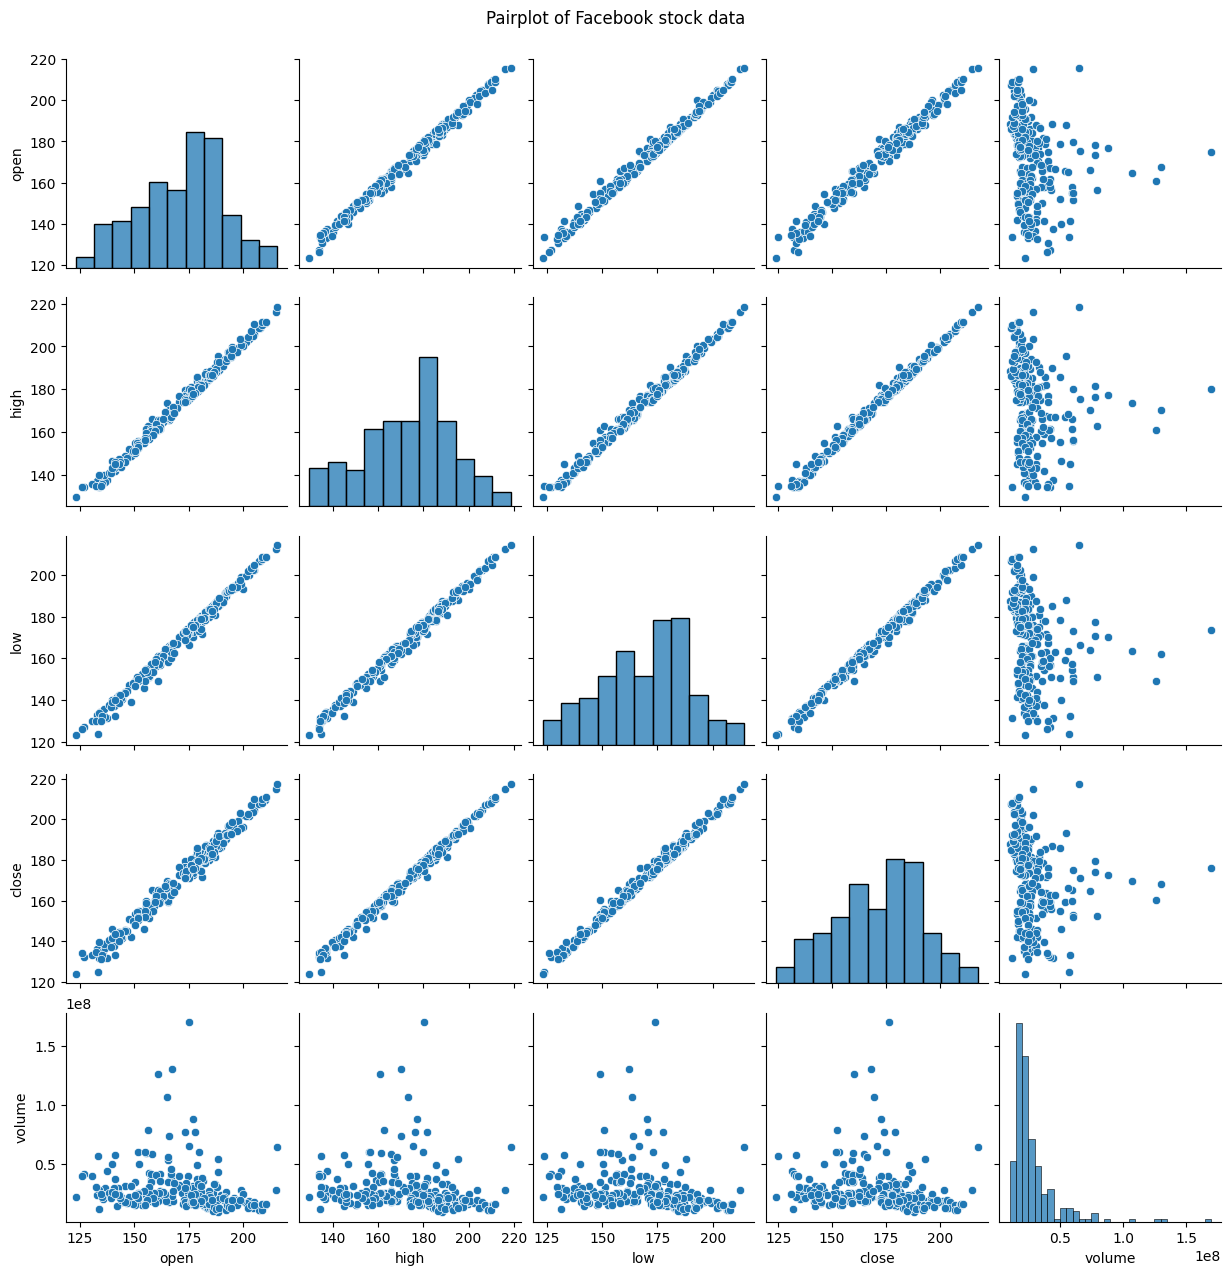

In [9]:
sns.pairplot(fb)
plt.suptitle('Pairplot of Facebook stock data', y=1.02)
plt.show()

This gives a comprehensive view of relationships. The diagonal shows distributions. Off-diagonal are scatter plots. I can see that all price columns are linearly related, and volume shows some non-linear patterns. It’s a bit overwhelming with many variables, but useful for quick exploration.

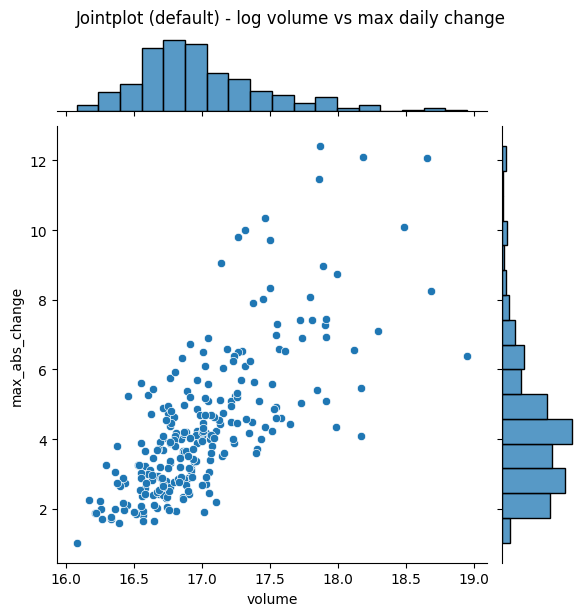

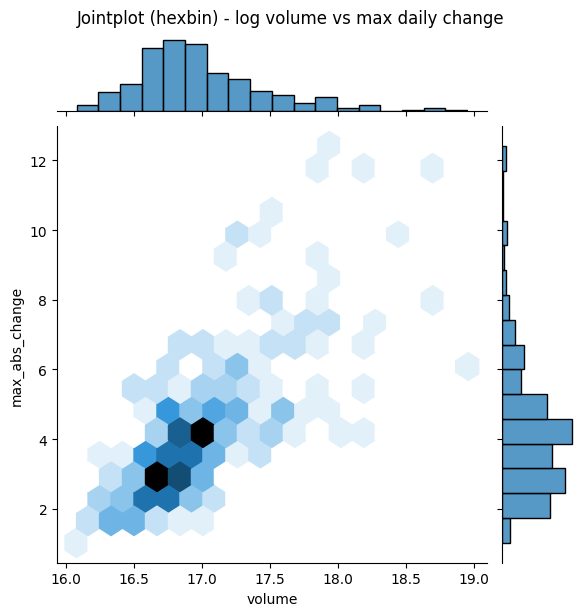

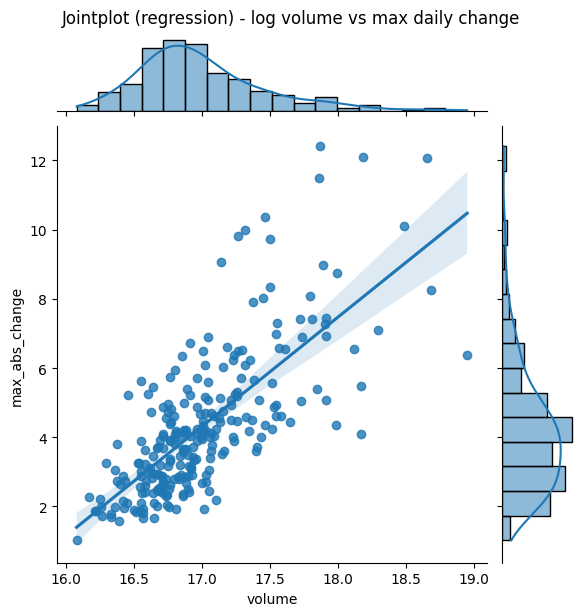

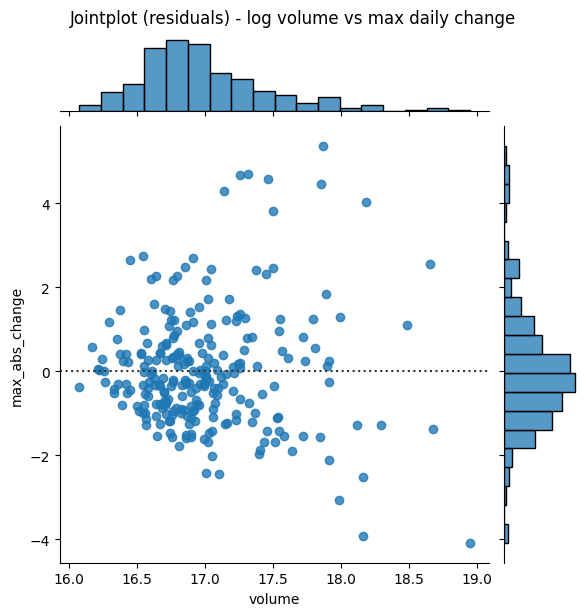

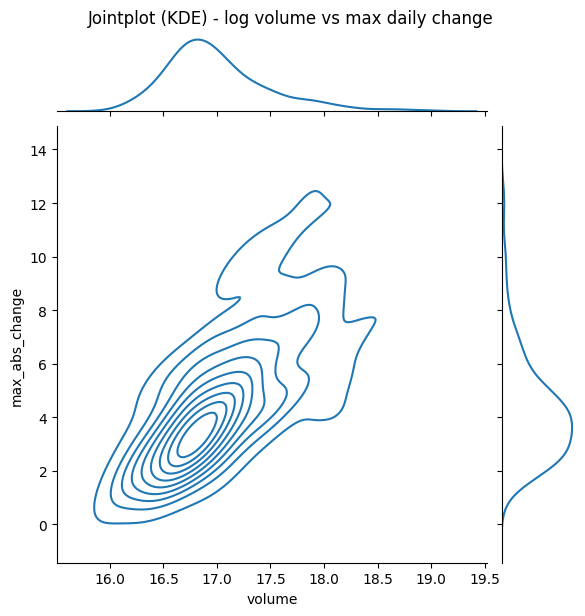

In [10]:
fb_joint = fb.assign(
    volume=np.log(fb.volume),
    max_abs_change=fb.high - fb.low
)

# Default jointplot (scatter + hist)
sns.jointplot(x='volume', y='max_abs_change', data=fb_joint)
plt.suptitle('Jointplot (default) - log volume vs max daily change', y=1.02)
plt.show()

# Hexbin plot
sns.jointplot(x='volume', y='max_abs_change', kind='hex', data=fb_joint)
plt.suptitle('Jointplot (hexbin) - log volume vs max daily change', y=1.02)
plt.show()

# Regression line + KDE
sns.jointplot(x='volume', y='max_abs_change', kind='reg', data=fb_joint)
plt.suptitle('Jointplot (regression) - log volume vs max daily change', y=1.02)
plt.show()

# Residuals
sns.jointplot(x='volume', y='max_abs_change', kind='resid', data=fb_joint)
plt.suptitle('Jointplot (residuals) - log volume vs max daily change', y=1.02)
plt.show()

# KDE contour
sns.jointplot(x='volume', y='max_abs_change', kind='kde', data=fb_joint)
plt.suptitle('Jointplot (KDE) - log volume vs max daily change', y=1.02)
plt.show()

Each kind gives a different perspective. The default scatter shows the raw data. Hexbin is great when points overlap a lot. The regression line shows a slight positive trend (maybe). Residuals help check linearity. KDE contours show density. I like how the marginal distributions are always there. This is a powerful way to understand bivariate relationships.

In [11]:
fb_reg_data = fb.assign(
    volume=np.log(fb.volume),
    max_abs_change=fb.high - fb.low
).iloc[:, -2:]

The PDF uses a custom reg_resid_plots function from an external module. To make this notebook self-contained, I’ll define a simplified version that plots regression and residuals side by side for each pair of columns (using itertools.permutations).

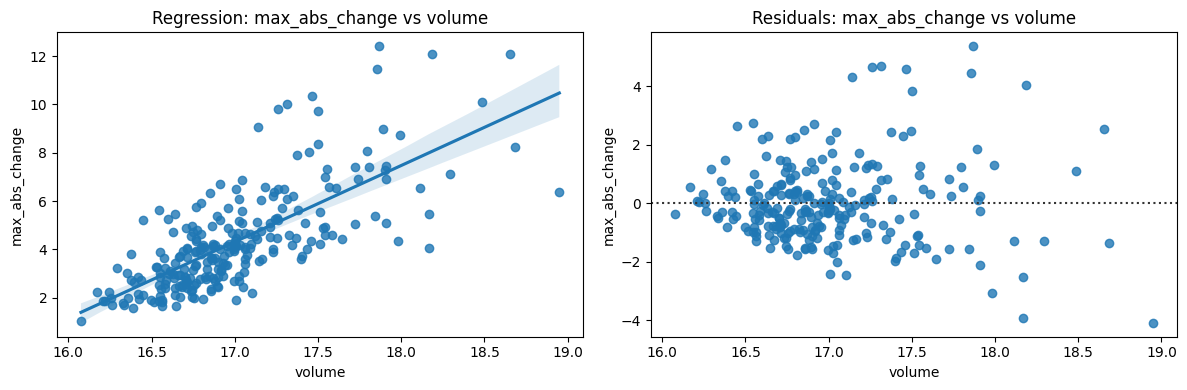

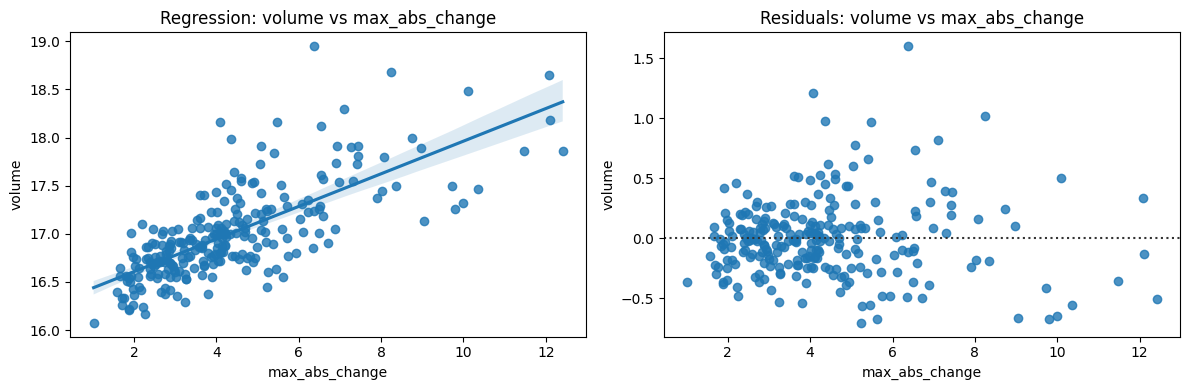

In [12]:
import itertools

def reg_resid_plots(data):
    """Plot regression and residual plots for all pairs of columns in data."""
    for col1, col2 in itertools.permutations(data.columns, 2):
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        # Regression plot
        sns.regplot(x=col1, y=col2, data=data, ax=axes[0])
        axes[0].set_title(f'Regression: {col2} vs {col1}')
        # Residual plot
        sns.residplot(x=col1, y=col2, data=data, ax=axes[1])
        axes[1].set_title(f'Residuals: {col2} vs {col1}')
        plt.tight_layout()
        plt.show()

reg_resid_plots(fb_reg_data)

The custom function plots both regression and residuals for each pair. Since we have two columns, we get two plots: volume vs max_abs_change and max_abs_change vs volume. The regression lines show a weak positive relationship. The residuals look randomly scattered, which suggests a linear model might be appropriate. This is a good way to check assumptions.

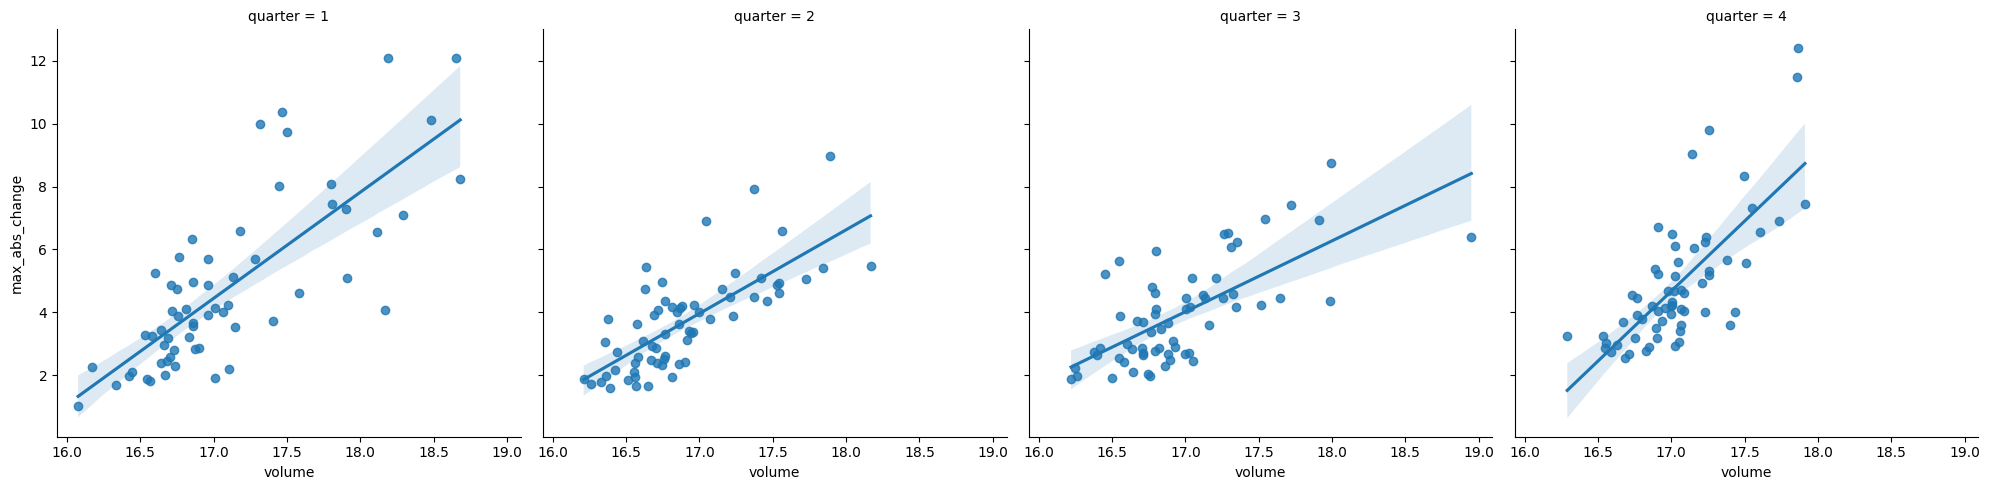

In [13]:
sns.lmplot(
    x='volume',
    y='max_abs_change',
    data=fb.assign(
        volume=np.log(fb.volume),
        max_abs_change=fb.high - fb.low,
        quarter=lambda x: x.index.quarter
    ),
    col='quarter'
)
plt.show()

Faceting by quarter shows that the relationship between volume and max daily change varies across the year. Q1 and Q2 seem to have a slight positive slope, while Q3 and Q4 appear flatter. This might indicate changing market dynamics.

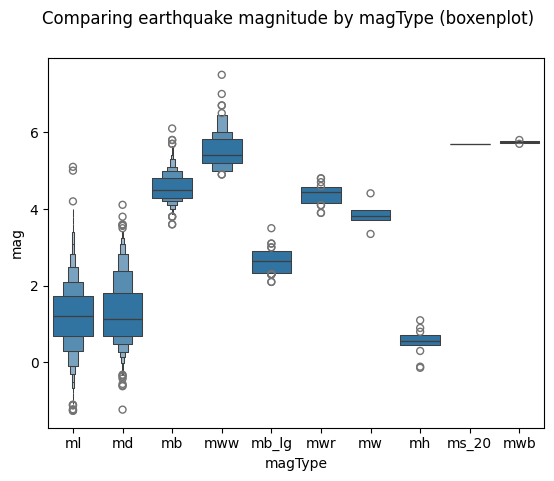

C:\Users\Rawr\AppData\Local\Temp\ipykernel_26256\4029546562.py:8: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


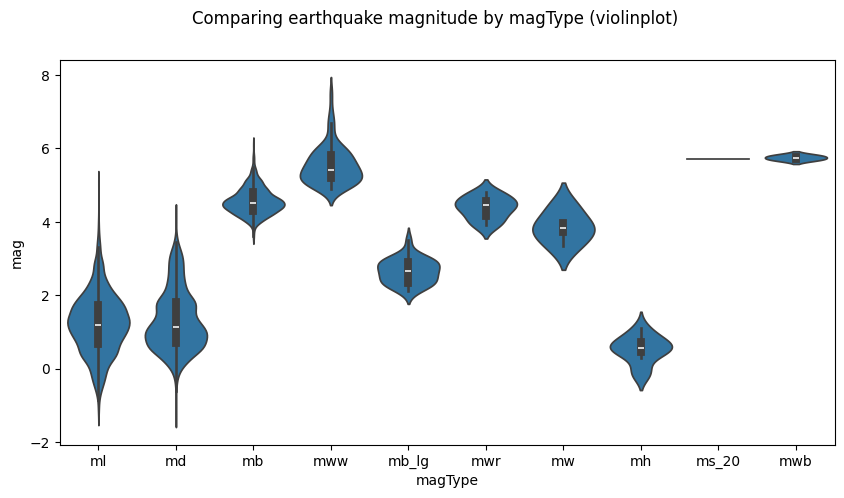

In [14]:
# Boxenplot
sns.boxenplot(x='magType', y='mag', data=quakes[['magType', 'mag']])
plt.suptitle('Comparing earthquake magnitude by magType (boxenplot)')
plt.show()

# Violinplot
fig, axes = plt.subplots(figsize=(10, 5))
sns.violinplot(
    x='magType', y='mag', data=quakes[['magType', 'mag']],
    ax=axes, scale='width'
)
plt.suptitle('Comparing earthquake magnitude by magType (violinplot)')
plt.show()

The boxenplot shows more quantiles than a standard box plot, giving a richer view of the distribution. The violinplot combines box plot and KDE, showing the full distribution shape. For magType, some types like md have a narrow range, while mb has a wide spread. Violin plots are my favorite because they show multimodality.

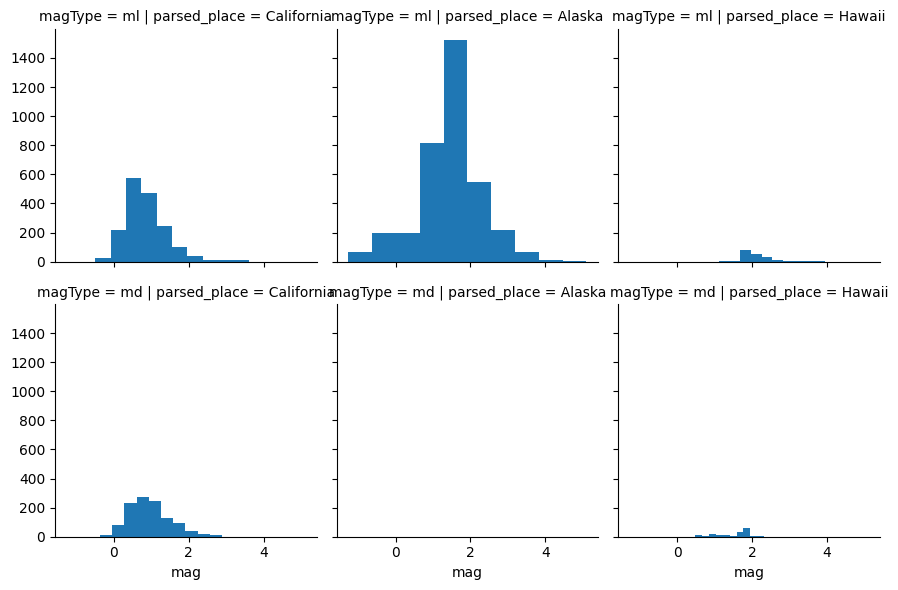

In [15]:
g = sns.FacetGrid(
    quakes[
        (quakes.parsed_place.isin(['California', 'Alaska', 'Hawaii'])) &
        (quakes.magType.isin(['ml', 'md']))
    ],
    row='magType',
    col='parsed_place'
)
g = g.map(plt.hist, 'mag')
plt.show()

This grid shows histograms for each place and magType combination. It’s clear that ml magnitudes are recorded more often in these places, and the distributions differ. For example, Alaska has more earthquakes with ml around 2-3, while California has a broader range. Faceting makes comparisons easy.

## Procedure 9.5

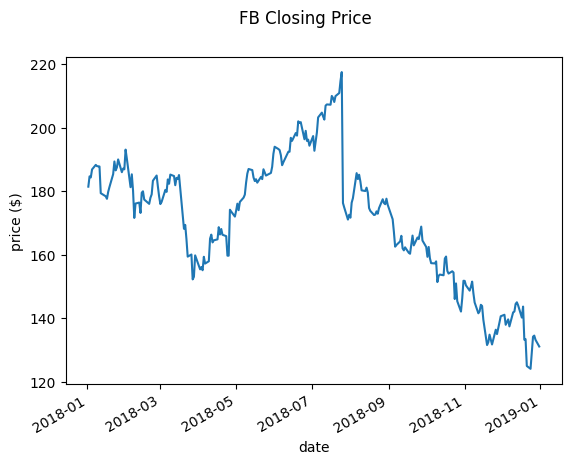

In [16]:
# Single plot with title and labels
fb.close.plot()
plt.suptitle('FB Closing Price')
plt.xlabel('date')
plt.ylabel('price ($)')
plt.show()

plt.suptitle() adds a title above the whole figure, which is fine for a single plot. The x and y labels are correctly placed.

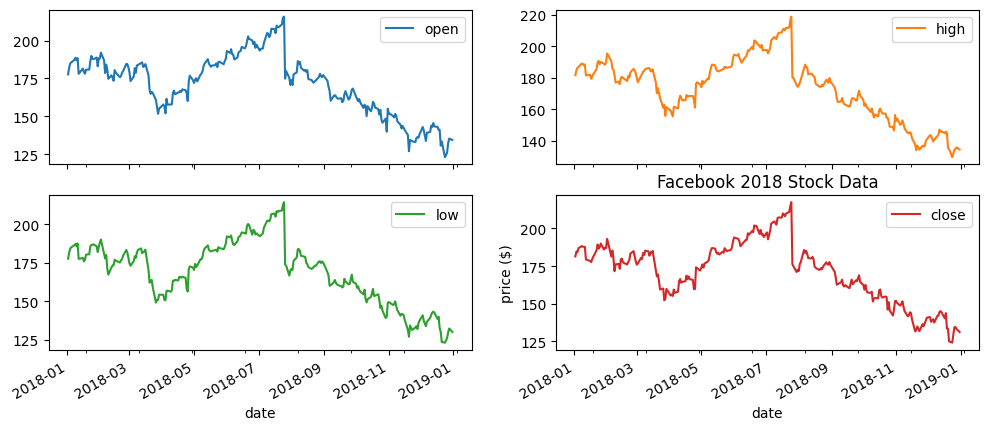

In [17]:
fb.iloc[:, :4].plot(subplots=True, layout=(2, 2), figsize=(12, 5))
plt.title('Facebook 2018 Stock Data')  # This only affects the last subplot
plt.xlabel('date')
plt.ylabel('price ($)')
plt.show()

The title only appears on the last subplot, and the xlabel/ylabel are not correctly applied to all. This is confusing. Using plt.suptitle() instead would fix it.

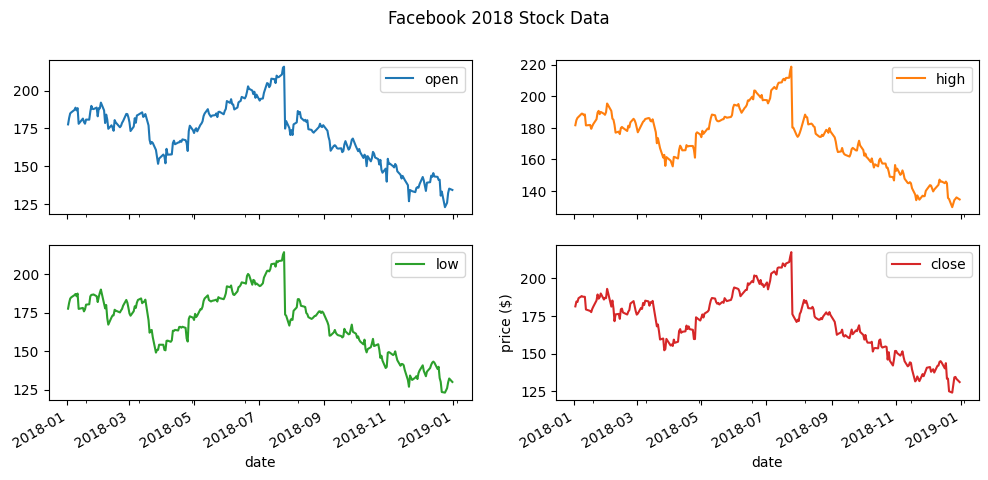

In [18]:
fb.iloc[:, :4].plot(subplots=True, layout=(2, 2), figsize=(12, 5))
plt.suptitle('Facebook 2018 Stock Data')
plt.xlabel('date')
plt.ylabel('price ($)')
plt.show()

Now the title is centered above all subplots. However, the xlabel and ylabel still only apply to the last subplot. To label all axes, we'd need to iterate, but for now, it's better.

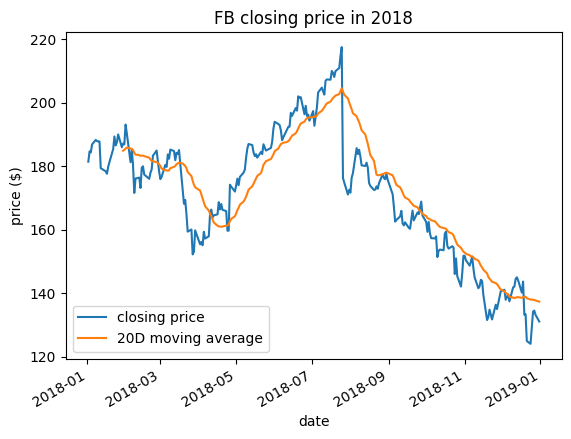

In [19]:
fb.assign(
    ma=lambda x: x.close.rolling(20).mean()
).plot(
    y=['close', 'ma'],
    title='FB closing price in 2018',
    label=['closing price', '20D moving average']
)
plt.legend(loc='lower left')
plt.ylabel('price ($)')
plt.show()

The legend is placed in the lower left as specified. It helps identify the lines. Without plt.legend(), the labels wouldn't show.



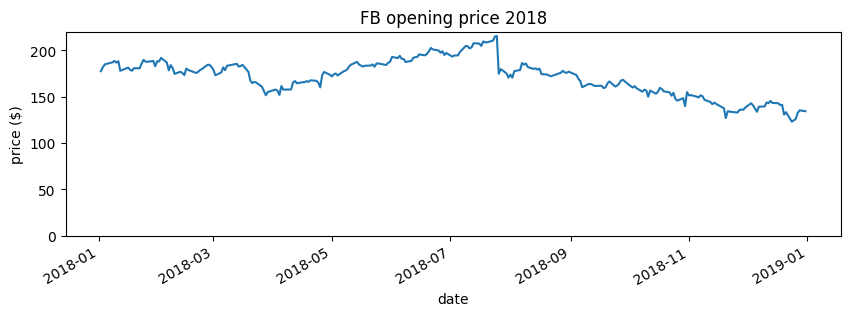

In [20]:
fb.open.plot(figsize=(10, 3), title='FB opening price 2018')
plt.ylim(0, None)  # set lower limit to 0, let matplotlib choose upper
plt.ylabel('price ($)')
plt.show()

Setting ylim(0, None) makes the y-axis start at 0, which can be useful for comparisons. The upper limit is automatically set.

ValueError: The number of FixedLocator locations (7), usually from a call to set_ticks, does not match the number of labels (6).

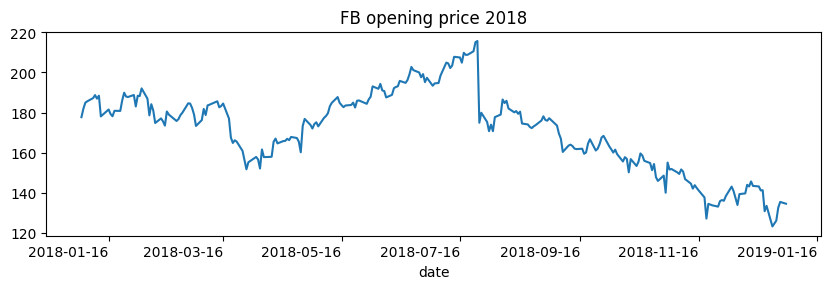

In [21]:
import calendar

fb.open.plot(figsize=(10, 3), rot=0, title='FB opening price 2018')
locs, labels = plt.xticks()
plt.xticks(locs + 15, calendar.month_name[1::2])
plt.ylabel('price ($)')
plt.show()

This shifts the tick positions by 15 days and labels with month names. It looks a bit messy because the ticks are not aligned with actual data points, but it's an example of custom tick labeling.

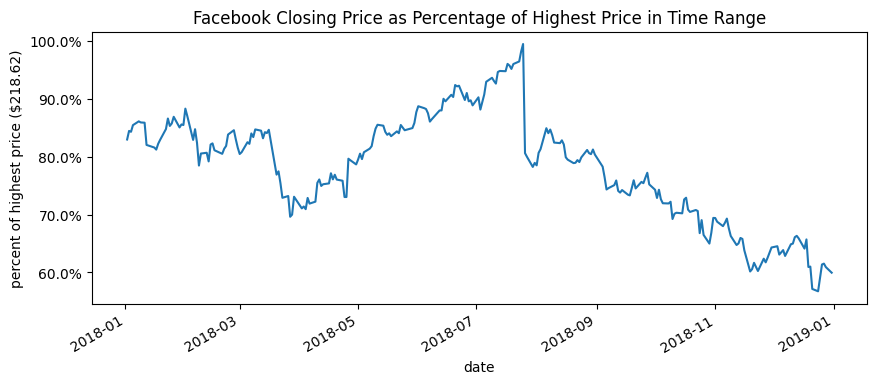

In [ ]:
import matplotlib.ticker as ticker

ax = fb.close.plot(figsize=(10, 4), title='Facebook Closing Price as Percentage of Highest Price in Time Range')
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=fb.high.max()))
ax.set_yticks([fb.high.max() * pct for pct in np.linspace(0.6, 1, num=5)])
ax.set_ylabel(f'percent of highest price (${fb.high.max():.2f})')
plt.show()

This converts y-axis to percentages relative to the highest price. The PercentFormatter makes it easy. I set ticks at 60%, 70%, 80%, 90%, 100%. This is useful for showing relative changes.

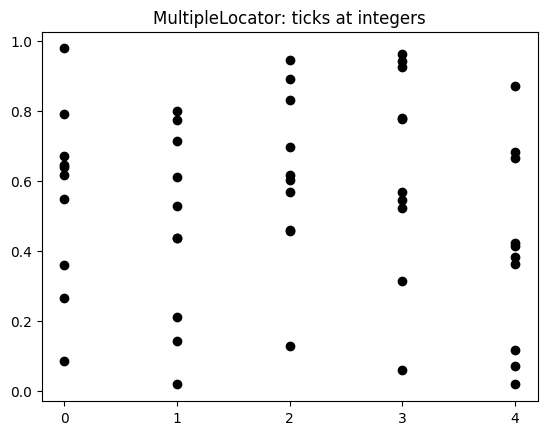

In [ ]:
fig, ax = plt.subplots(1, 1)
np.random.seed(0)
ax.plot(np.tile(np.arange(0, 5), 10), np.random.rand(50), 'ko')
ax.get_xaxis().set_major_locator(ticker.MultipleLocator(base=1))
ax.set_title('MultipleLocator: ticks at integers')
plt.show()

Without MultipleLocator, the x-axis might show decimals. Setting base=1 forces ticks at integer positions (0,1,2,3,4). This cleans up the plot when x values are discrete.

## Procedure 9.6

In [22]:
%matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

Using matplotlib backend: module://matplotlib_inline.backend_inline


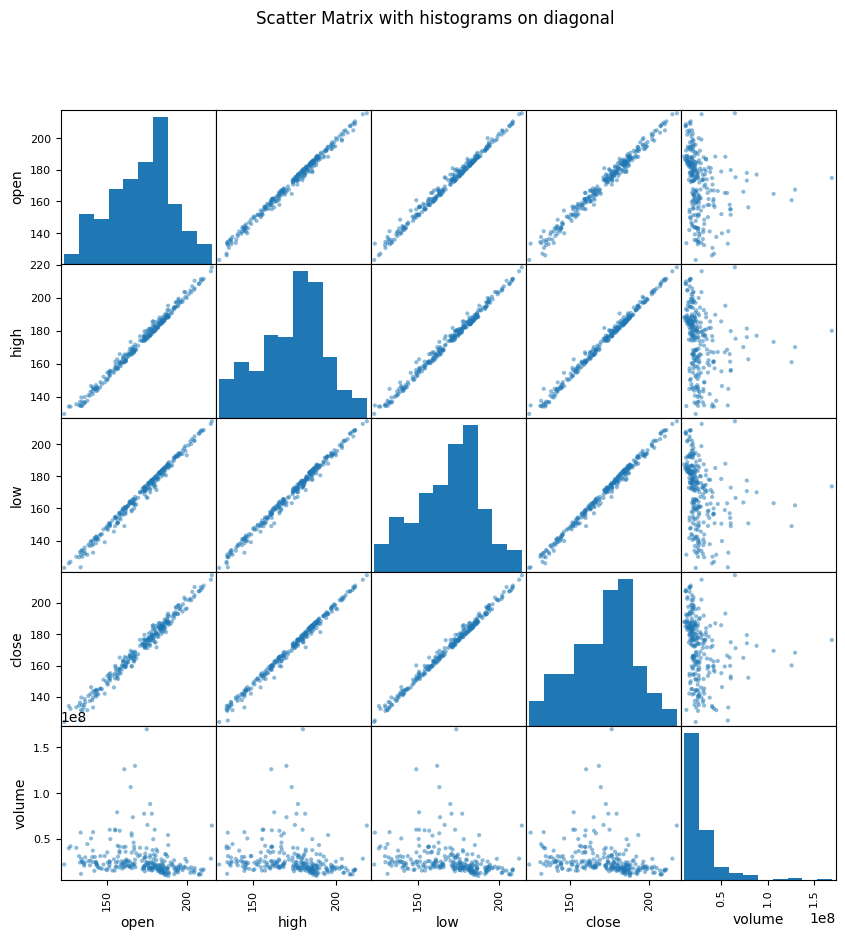

In [23]:
from pandas.plotting import scatter_matrix

scatter_matrix(fb, figsize=(10, 10))
plt.suptitle('Scatter Matrix with histograms on diagonal')
plt.show()

The scatter matrix shows pairwise scatter plots. On the diagonal are histograms of each variable. This is similar to seaborn's pairplot but with different styling. It's useful for quick correlation checks, but the default histograms can be changed.

array([[<Axes: xlabel='open', ylabel='open'>,
        <Axes: xlabel='high', ylabel='open'>,
        <Axes: xlabel='low', ylabel='open'>,
        <Axes: xlabel='close', ylabel='open'>,
        <Axes: xlabel='volume', ylabel='open'>],
       [<Axes: xlabel='open', ylabel='high'>,
        <Axes: xlabel='high', ylabel='high'>,
        <Axes: xlabel='low', ylabel='high'>,
        <Axes: xlabel='close', ylabel='high'>,
        <Axes: xlabel='volume', ylabel='high'>],
       [<Axes: xlabel='open', ylabel='low'>,
        <Axes: xlabel='high', ylabel='low'>,
        <Axes: xlabel='low', ylabel='low'>,
        <Axes: xlabel='close', ylabel='low'>,
        <Axes: xlabel='volume', ylabel='low'>],
       [<Axes: xlabel='open', ylabel='close'>,
        <Axes: xlabel='high', ylabel='close'>,
        <Axes: xlabel='low', ylabel='close'>,
        <Axes: xlabel='close', ylabel='close'>,
        <Axes: xlabel='volume', ylabel='close'>],
       [<Axes: xlabel='open', ylabel='volume'>,
        <Axes: xlabe

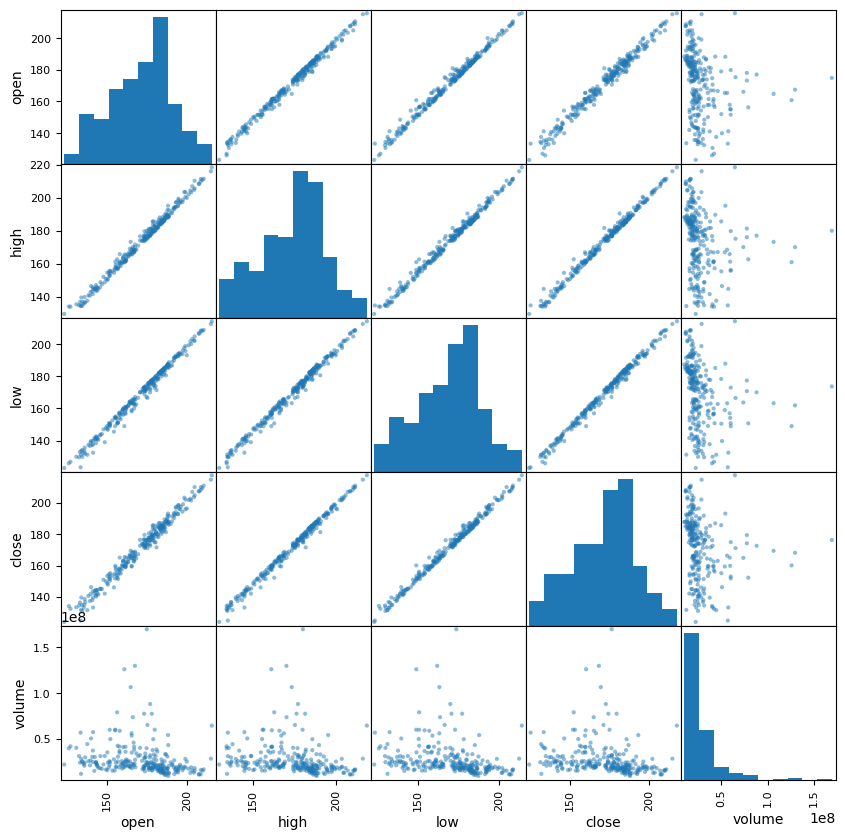

In [26]:
scatter_matrix(fb, figsize=(10, 10))

array([[<Axes: xlabel='open', ylabel='open'>,
        <Axes: xlabel='high', ylabel='open'>,
        <Axes: xlabel='low', ylabel='open'>,
        <Axes: xlabel='close', ylabel='open'>,
        <Axes: xlabel='volume', ylabel='open'>],
       [<Axes: xlabel='open', ylabel='high'>,
        <Axes: xlabel='high', ylabel='high'>,
        <Axes: xlabel='low', ylabel='high'>,
        <Axes: xlabel='close', ylabel='high'>,
        <Axes: xlabel='volume', ylabel='high'>],
       [<Axes: xlabel='open', ylabel='low'>,
        <Axes: xlabel='high', ylabel='low'>,
        <Axes: xlabel='low', ylabel='low'>,
        <Axes: xlabel='close', ylabel='low'>,
        <Axes: xlabel='volume', ylabel='low'>],
       [<Axes: xlabel='open', ylabel='close'>,
        <Axes: xlabel='high', ylabel='close'>,
        <Axes: xlabel='low', ylabel='close'>,
        <Axes: xlabel='close', ylabel='close'>,
        <Axes: xlabel='volume', ylabel='close'>],
       [<Axes: xlabel='open', ylabel='volume'>,
        <Axes: xlabe

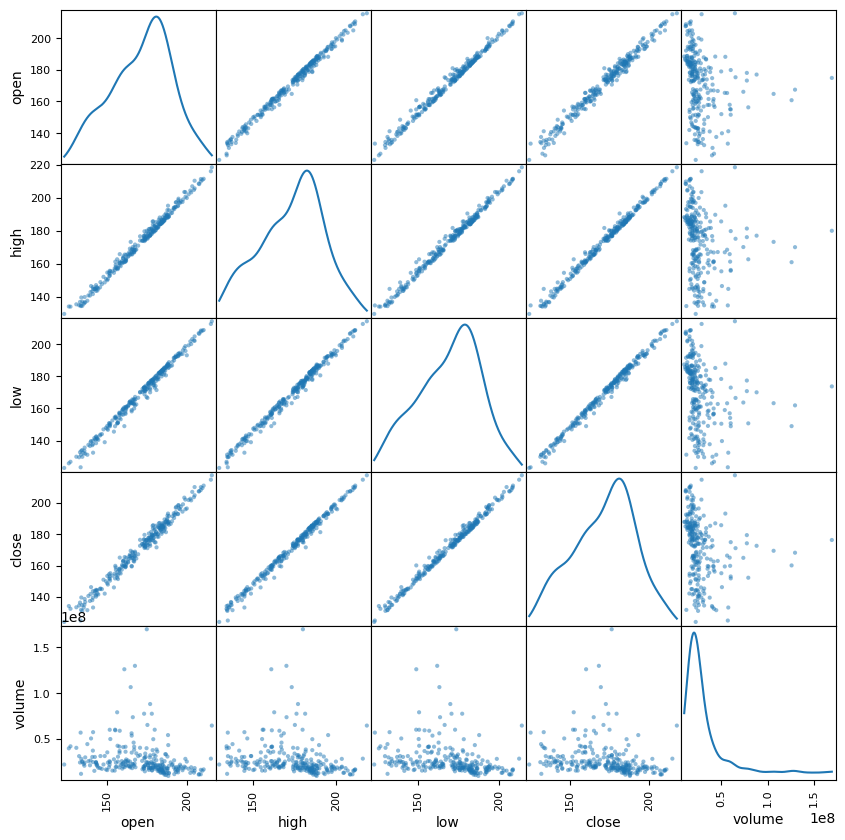

In [27]:
scatter_matrix(fb, figsize=(10, 10), diagonal='kde')

Now the diagonal shows kernel density estimates instead of histograms. KDE gives a smoother distribution. I prefer KDE for continuous data.

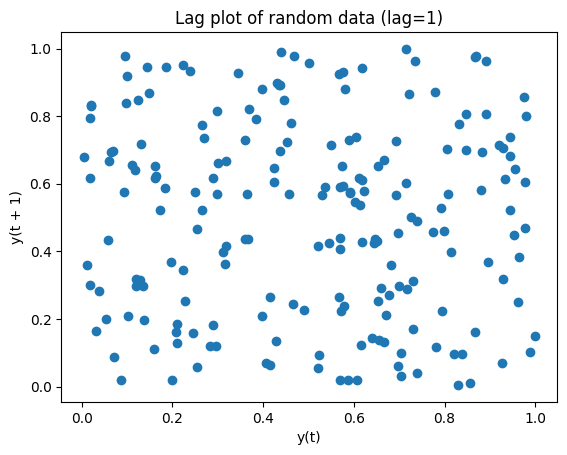

In [28]:
from pandas.plotting import lag_plot

# Random data (no autocorrelation)
np.random.seed(0)
lag_plot(pd.Series(np.random.random(size=200)))
plt.title('Lag plot of random data (lag=1)')
plt.show()

Random data shows no pattern; points are scattered randomly. This indicates no autocorrelation.

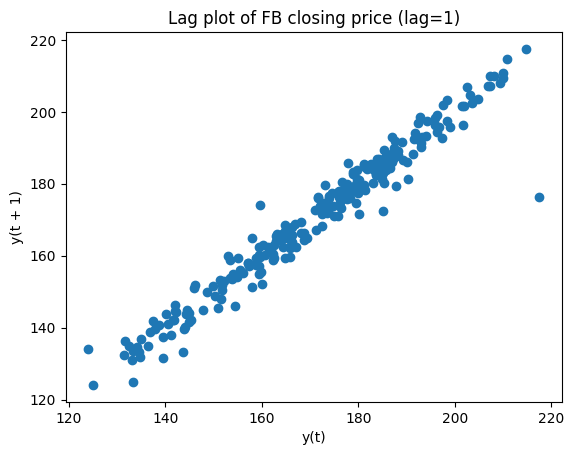

In [29]:
# Facebook closing price (highly autocorrelated)
lag_plot(fb.close)
plt.title('Lag plot of FB closing price (lag=1)')
plt.show()

There's a clear linear pattern, indicating strong autocorrelation. Today's price is highly correlated with yesterday's price.

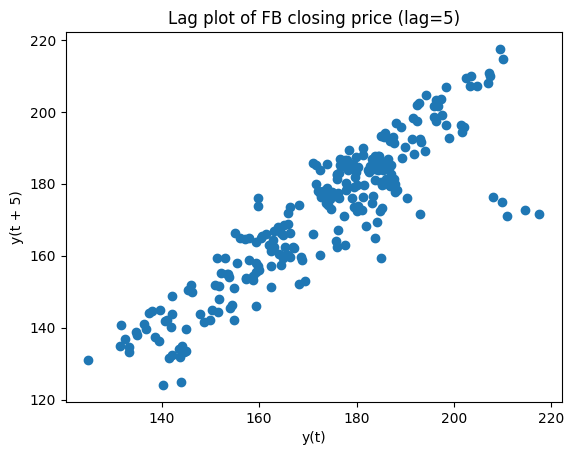

In [30]:
lag_plot(fb.close, lag=5)
plt.title('Lag plot of FB closing price (lag=5)')
plt.show()

Even with a 5-day lag, there's still a strong linear relationship, though slightly more spread. Stock prices are persistent.

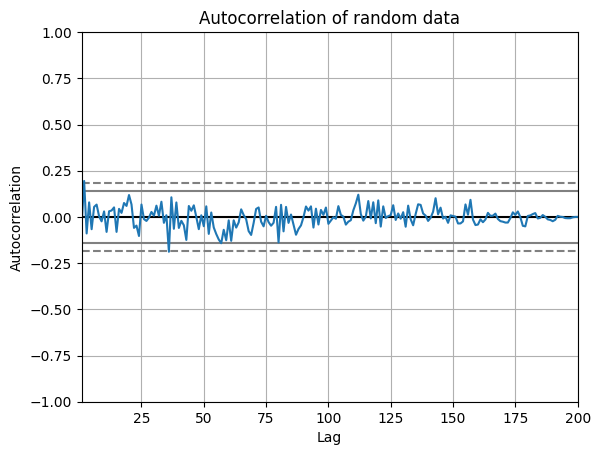

In [31]:
from pandas.plotting import autocorrelation_plot

# Random data
np.random.seed(0)
autocorrelation_plot(pd.Series(np.random.random(size=200)))
plt.title('Autocorrelation of random data')
plt.show()

The autocorrelation for random data stays within the confidence bands (dotted lines), indicating no significant autocorrelation.

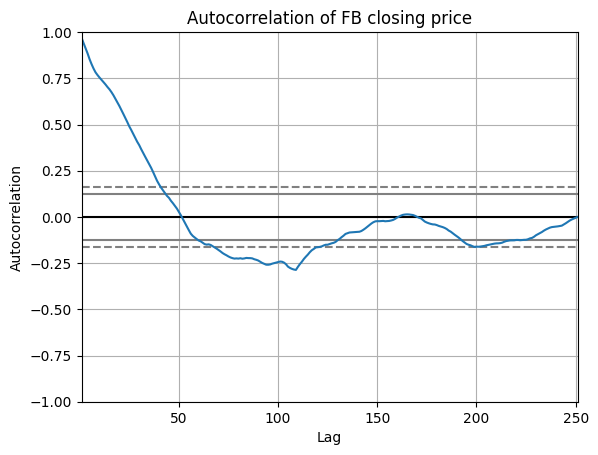

In [32]:
autocorrelation_plot(fb.close)
plt.title('Autocorrelation of FB closing price')
plt.show()

The autocorrelation starts near 1 and decays slowly, staying above the confidence bands for many lags. This confirms strong autocorrelation, typical of financial time series.

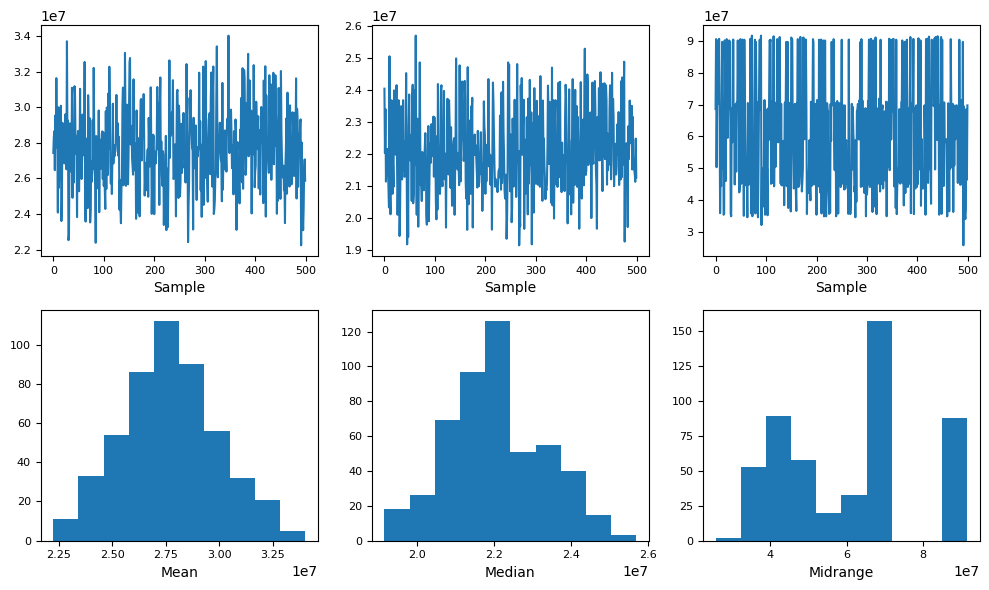

In [33]:
from pandas.plotting import bootstrap_plot

fig = bootstrap_plot(fb.volume, fig=plt.figure(figsize=(10, 6)))
plt.show()

The bootstrap plot shows histograms of bootstrap samples for mean, median, and midrange. The vertical lines indicate the original statistic. This helps understand the variability. For volume, the mean is around 35 million, and the bootstrap distribution gives a sense of confidence intervals.

# Supplementary Act

## 1.

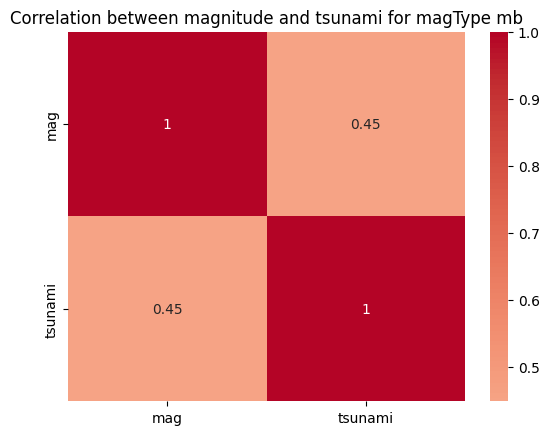

In [34]:
mb_data = quakes[quakes.magType == 'mb'][['mag', 'tsunami']]

corr_mb = mb_data.corr()

sns.heatmap(corr_mb, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation between magnitude and tsunami for magType mb')
plt.show()

## 2.

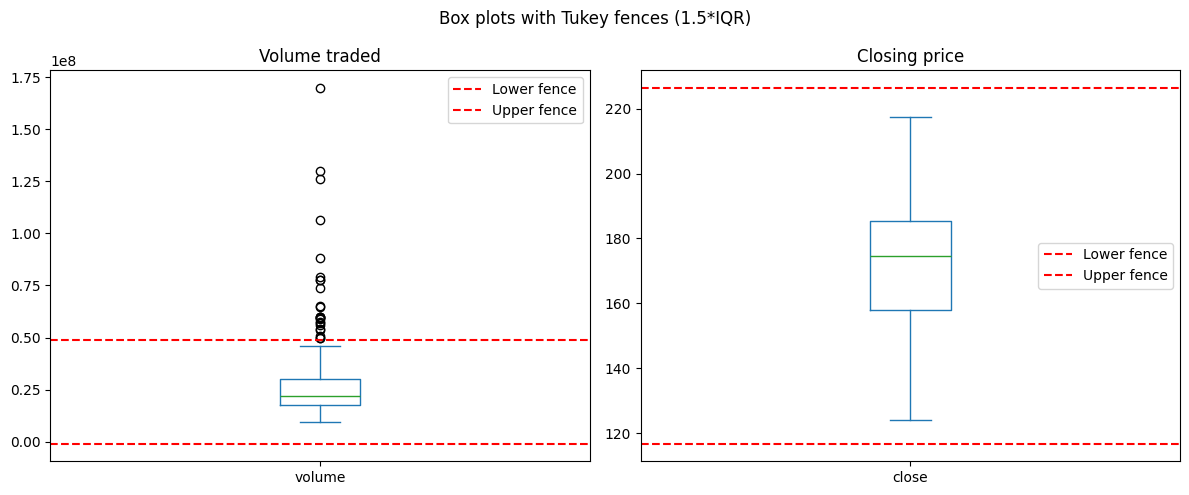

In [35]:
vol_Q1 = fb.volume.quantile(0.25)
vol_Q3 = fb.volume.quantile(0.75)
vol_IQR = vol_Q3 - vol_Q1
vol_lower = vol_Q1 - 1.5 * vol_IQR
vol_upper = vol_Q3 + 1.5 * vol_IQR

close_Q1 = fb.close.quantile(0.25)
close_Q3 = fb.close.quantile(0.75)
close_IQR = close_Q3 - close_Q1
close_lower = close_Q1 - 1.5 * close_IQR
close_upper = close_Q3 + 1.5 * close_IQR

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fb.volume.plot(kind='box', ax=axes[0], title='Volume traded')
axes[0].axhline(vol_lower, color='r', linestyle='--', label='Lower fence')
axes[0].axhline(vol_upper, color='r', linestyle='--', label='Upper fence')
axes[0].legend()

fb.close.plot(kind='box', ax=axes[1], title='Closing price')
axes[1].axhline(close_lower, color='r', linestyle='--', label='Lower fence')
axes[1].axhline(close_upper, color='r', linestyle='--', label='Upper fence')
axes[1].legend()

plt.suptitle('Box plots with Tukey fences (1.5*IQR)')
plt.tight_layout()
plt.show()

## 3.

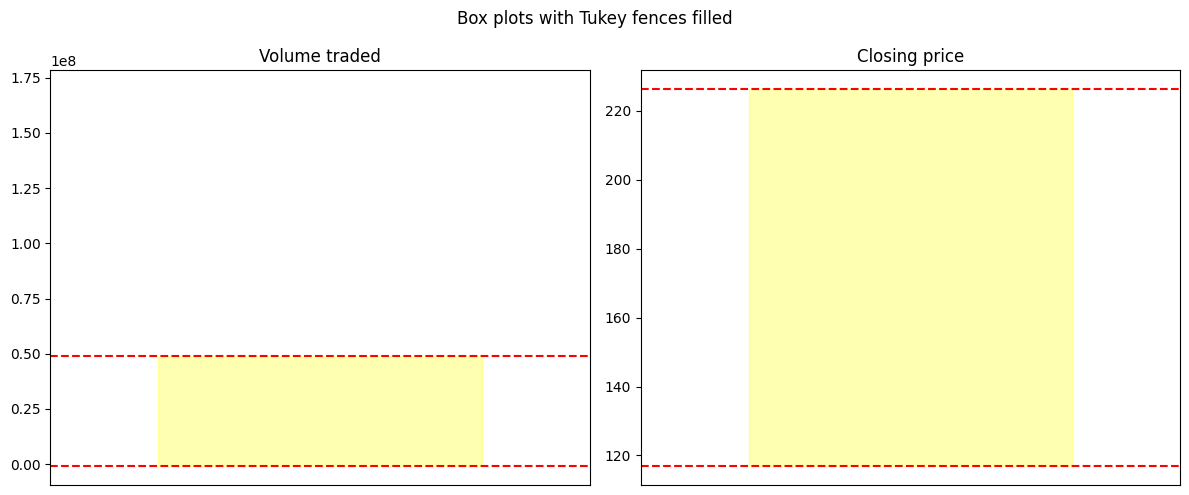

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fb.volume.plot(kind='box', ax=axes[0], title='Volume traded')
axes[0].axhline(vol_lower, color='r', linestyle='--')
axes[0].axhline(vol_upper, color='r', linestyle='--')
axes[0].fill_between(x=[-0.3, 0.3], y1=vol_lower, y2=vol_upper, alpha=0.3, color='yellow')
axes[0].set_xlim(-0.5, 0.5)

fb.close.plot(kind='box', ax=axes[1], title='Closing price')
axes[1].axhline(close_lower, color='r', linestyle='--')
axes[1].axhline(close_upper, color='r', linestyle='--')
axes[1].fill_between(x=[-0.3, 0.3], y1=close_lower, y2=close_upper, alpha=0.3, color='yellow')
axes[1].set_xlim(-0.5, 0.5)

plt.suptitle('Box plots with Tukey fences filled')
plt.tight_layout()
plt.show()

## 4.

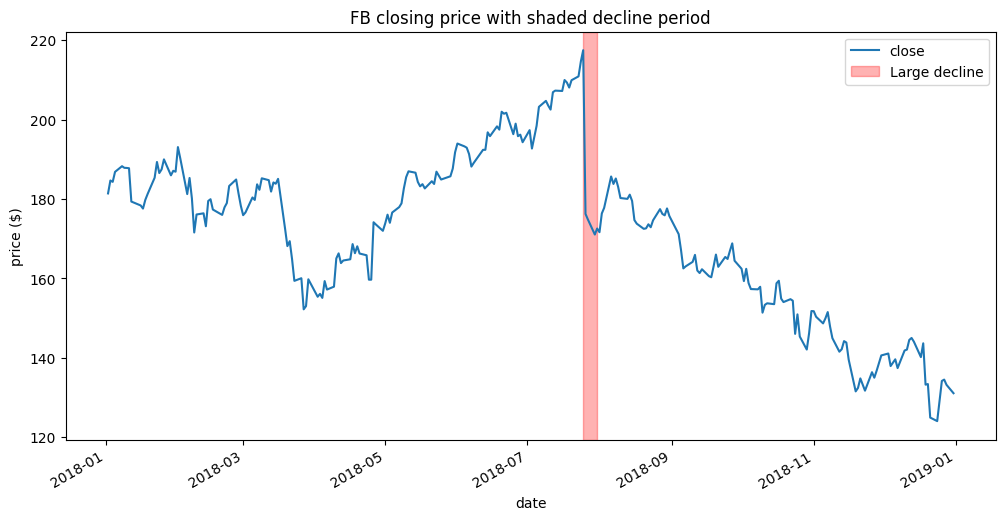

In [37]:
fb.close.plot(figsize=(12, 6), title='FB closing price with shaded decline period')
plt.axvspan('2018-07-25', '2018-07-31', alpha=0.3, color='red', label='Large decline')
plt.ylabel('price ($)')
plt.legend()
plt.show()

## 5.

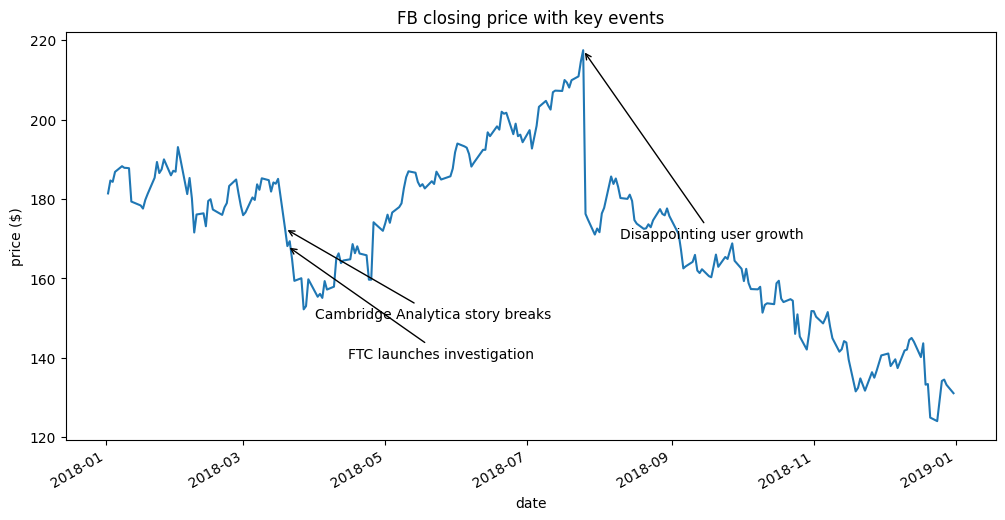

In [38]:
fb.close.plot(figsize=(12, 6), title='FB closing price with key events')
plt.ylabel('price ($)')

plt.annotate('Disappointing user growth', xy=('2018-07-25', fb.loc['2018-07-25', 'close']),
             xytext=('2018-08-10', 170),
             arrowprops=dict(arrowstyle='->'))

plt.annotate('Cambridge Analytica story breaks', xy=('2018-03-19', fb.loc['2018-03-19', 'close']),
             xytext=('2018-04-01', 150),
             arrowprops=dict(arrowstyle='->'))

plt.annotate('FTC launches investigation', xy=('2018-03-20', fb.loc['2018-03-20', 'close']),
             xytext=('2018-04-15', 140),
             arrowprops=dict(arrowstyle='->'))

plt.show()

## 6.

C:\Users\Rawr\AppData\Local\Temp\ipykernel_26256\907274865.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap(cmap, len(pairs))


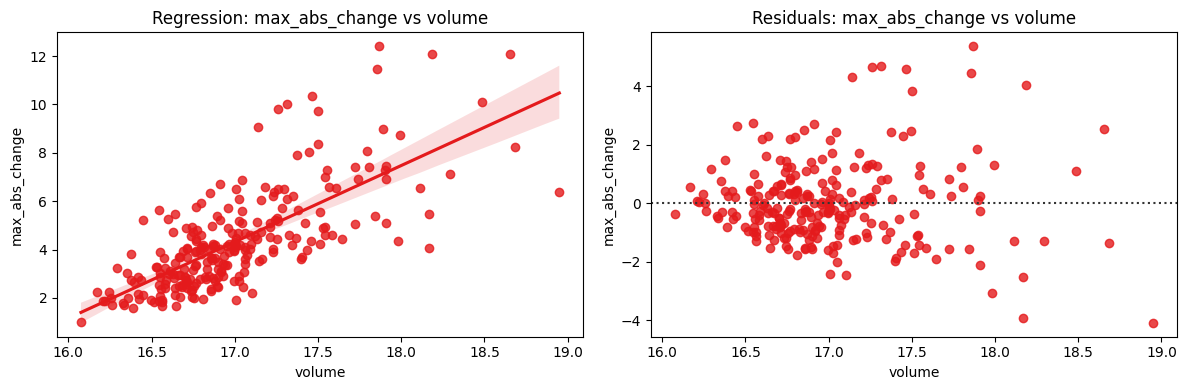

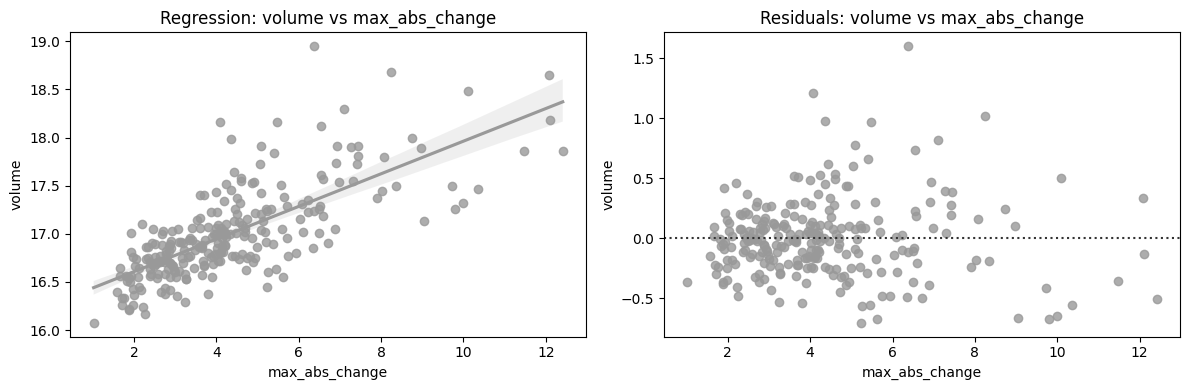

In [39]:
def reg_resid_plots_colormap(data, cmap='Set1'):
    """Plot regression and residual plots for all pairs using a colormap."""
    pairs = list(itertools.permutations(data.columns, 2))
    colors = plt.cm.get_cmap(cmap, len(pairs))
    for idx, (col1, col2) in enumerate(pairs):
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        sns.regplot(x=col1, y=col2, data=data, ax=axes[0], color=colors(idx))
        axes[0].set_title(f'Regression: {col2} vs {col1}')
        sns.residplot(x=col1, y=col2, data=data, ax=axes[1], color=colors(idx))
        axes[1].set_title(f'Residuals: {col2} vs {col1}')
        plt.tight_layout()
        plt.show()

reg_resid_plots_colormap(fb_reg_data, cmap='Set1')

# Conclusion

### Conclusion:

I went through three sections which are Introduction to Seaborn, Formatting Plots, and the pandas.plotting subpackage. I copied all the code from the PDFs and ran it with the provided datasets. Along the way, I added my own observations and analysis, trying to understand what each plot shows and why it's useful.

I learned that Seaborn makes it easy to create complex statistical plots like swarm plots, heatmaps, and joint plots with just a few lines of code. Formatting plots with titles, labels, legends, and custom ticks helps make the visualizations clearer and more professional. The pandas.plotting subpackage provides specialized plots like lag plots and autocorrelation plots that are great for time series analysis.

The supplementary exercises were challenging but fun. I had to apply what I learned to create box plots with Tukey fences, annotate events, and even modify a function to use colormaps. It felt good to figure out how to fill areas between bounds and shade specific date ranges.

This module taught me that visualizing data is not just about making pretty pictures it's about revealing insights and telling a story. I still have a lot to learn, but I feel more confident now in using Python for data visualization.